# Experiment: Stratified Robustness Downstream Experiment

这个 notebook 对应 `scripts/trishift/analysis/stratified_benchmark.py`。

目的：
- 不只看总体均值，而是按难度分层看模型在 hard cases 上的表现。
- 当前默认 strata 包括 `Norman subgroup`、effect strength、train-test distance、DEG difficulty。


In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

from IPython.display import Image, display

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not ((repo_root / "scripts").exists() and (repo_root / "configs").exists()):
    repo_root = repo_root.parent
if not ((repo_root / "scripts").exists() and (repo_root / "configs").exists()):
    raise FileNotFoundError(f"Could not locate repo root from {Path.cwd()}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.stratified_benchmark as stratified_benchmark
importlib.reload(stratified_benchmark)

run_stratified_benchmark = stratified_benchmark.run_stratified_benchmark
SUMMARY_METRICS = stratified_benchmark.SUMMARY_METRICS

repo_root


WindowsPath('E:/CODE/trishift')

## Parameters

如果只是 smoke test，先用 `adamson + trishift_nearest + split1`。如果要看论文级分层，再换到 `norman`。


In [2]:
dataset = "adamson"
models = ["trishift_nearest", "scouter", "gears", "genepert", "scgpt"]
split_ids = [1]
paths_path = (repo_root / "configs" / "paths.yaml").resolve()
if not paths_path.exists():
    raise FileNotFoundError(paths_path)
systema_root = None
out_root = (repo_root / "artifacts" / "analysis" / f"stratified_{dataset}").resolve()
out_root.mkdir(parents=True, exist_ok=True)

result = run_stratified_benchmark(
    dataset=dataset,
    models=models,
    split_ids=split_ids,
    paths_path=paths_path,
    systema_root=systema_root,
    out_root=out_root,
)

print(f"out_dir: {result['out_dir']}")
print(f"summary metrics: {SUMMARY_METRICS}")


out_dir: E:\CODE\trishift\artifacts\analysis\stratified_adamson
summary metrics: ['pearson', 'nmse', 'deg_mean_r2', 'systema_corr_20de_allpert', 'systema_corr_deg_r2', 'scpram_r2_degs_var_mean']


## Tables

推荐顺序：先看 `condition_difficulty_metadata` 是否合理，再看 `stratified_summary` 和 `winrate`。


In [3]:
display(result["metric_summary_df"])
display(result["metadata_df"].head(30))
display(result["stratified_df"].head(30))
display(result["summary_df"].head(30))
display(result["win_df"].head(30))


,model_name,pearson,nmse,deg_mean_r2,systema_corr_20de_allpert,systema_corr_deg_r2,scpram_r2_degs_var_mean
0,gears,0.961559,0.172602,0.793200,-0.603978,-1.412756,NaN
1,genepert,0.856408,0.221887,0.754143,0.419430,0.018244,NaN
2,scgpt,0.838913,0.326258,0.614317,-0.169610,-1.261710,0.063911
3,scouter,0.889031,0.203938,0.770166,0.335295,-0.262145,0.373835
4,trishift_nearest,0.937794,0.164736,0.810038,0.428987,-0.106224,0.796918


,dataset,split_id,condition,subgroup,truth_ctrl_shift_norm,deg_count,train_test_distance,effect_strength_bin,train_distance_bin,deg_difficulty_bin
0,adamson,1,TELO2+ctrl,,5.508454,19,0.509583,medium,far,easy
1,adamson,1,MANF+ctrl,,4.910699,19,0.469269,weak,medium,easy
2,adamson,1,ATP5B+ctrl,,5.622799,19,0.502805,medium,far,easy
3,adamson,1,MRPL39+ctrl,,5.359105,19,0.508735,weak,far,easy
4,adamson,1,DERL2+ctrl,,6.118115,19,0.525616,strong,far,easy
5,adamson,1,CARS+ctrl,,9.810048,19,0.411524,strong,medium,easy
6,adamson,1,SCYL1+ctrl,,5.340434,19,0.496986,weak,medium,medium
7,adamson,1,COPB1+ctrl,,5.750762,20,0.352895,medium,near,hard
8,adamson,1,SPCS2+ctrl,,4.967551,19,0.256816,weak,near,medium
9,adamson,1,SRP72+ctrl,,5.987869,19,0.227714,medium,near,medium


,dataset,model_name,stratum_name,stratum_value,n_rows,pearson,nmse,deg_mean_r2,systema_corr_20de_allpert,systema_corr_deg_r2,scpram_r2_degs_var_mean
0,adamson,gears,effect_strength_bin,medium,2,0.961559,0.172602,0.793200,-0.603978,-1.412756,NaN
1,adamson,genepert,effect_strength_bin,medium,5,0.925186,0.136773,0.826245,0.551163,0.140692,NaN
2,adamson,genepert,effect_strength_bin,strong,6,0.964317,0.221879,0.759026,-0.006659,-0.202735,NaN
3,adamson,genepert,effect_strength_bin,weak,6,0.694097,0.290047,0.691861,0.733198,0.128996,NaN
4,adamson,scgpt,effect_strength_bin,medium,5,0.910063,0.234446,0.685471,-0.130029,-0.787132,0.023899
5,adamson,scgpt,effect_strength_bin,strong,6,0.938086,0.327895,0.617828,-0.283454,-1.653752,0.132923
6,adamson,scgpt,effect_strength_bin,weak,6,0.683307,0.400141,0.551499,-0.089618,-1.354575,0.029597
7,adamson,scouter,effect_strength_bin,medium,5,0.938644,0.124542,0.847296,0.707601,0.305862,0.305862
8,adamson,scouter,effect_strength_bin,strong,6,0.937585,0.221472,0.745780,-0.088921,-0.692604,0.472527
9,adamson,scouter,effect_strength_bin,weak,6,0.800128,0.250366,0.731667,0.434360,-0.352585,0.329855


,model_name,stratum_name,stratum_value,pearson,nmse,deg_mean_r2,systema_corr_20de_allpert,systema_corr_deg_r2,scpram_r2_degs_var_mean
0,gears,deg_difficulty_bin,hard,0.954324,0.163542,0.834202,-0.554471,-1.378221,NaN
1,gears,deg_difficulty_bin,medium,0.968794,0.181662,0.752197,-0.653486,-1.447291,NaN
2,gears,effect_strength_bin,medium,0.961559,0.172602,0.793200,-0.603978,-1.412756,NaN
3,gears,train_distance_bin,near,0.961559,0.172602,0.793200,-0.603978,-1.412756,NaN
4,genepert,deg_difficulty_bin,easy,0.962114,0.121403,0.839876,0.482817,-0.071365,NaN
5,genepert,deg_difficulty_bin,hard,0.664660,0.370919,0.612125,0.466812,0.073603,NaN
6,genepert,deg_difficulty_bin,medium,0.963154,0.160299,0.824908,0.283457,0.049519,NaN
7,genepert,effect_strength_bin,medium,0.925186,0.136773,0.826245,0.551163,0.140692,NaN
8,genepert,effect_strength_bin,strong,0.964317,0.221879,0.759026,-0.006659,-0.202735,NaN
9,genepert,effect_strength_bin,weak,0.694097,0.290047,0.691861,0.733198,0.128996,NaN


,dataset,stratum_name,stratum_value,best_pearson,best_nmse,best_deg_mean_r2,best_systema_corr_20de_allpert,best_systema_corr_deg_r2,best_scpram_r2_degs_var_mean
0,adamson,deg_difficulty_bin,easy,genepert,trishift_nearest,scouter,scouter,genepert,trishift_nearest
1,adamson,deg_difficulty_bin,hard,gears,gears,gears,genepert,trishift_nearest,trishift_nearest
2,adamson,deg_difficulty_bin,medium,gears,genepert,genepert,trishift_nearest,trishift_nearest,trishift_nearest
3,adamson,effect_strength_bin,medium,gears,scouter,scouter,scouter,scouter,trishift_nearest
4,adamson,effect_strength_bin,strong,genepert,trishift_nearest,trishift_nearest,trishift_nearest,genepert,trishift_nearest
5,adamson,effect_strength_bin,weak,trishift_nearest,trishift_nearest,trishift_nearest,genepert,trishift_nearest,trishift_nearest
6,adamson,train_distance_bin,far,genepert,genepert,genepert,genepert,genepert,trishift_nearest
7,adamson,train_distance_bin,medium,trishift_nearest,trishift_nearest,trishift_nearest,trishift_nearest,trishift_nearest,trishift_nearest
8,adamson,train_distance_bin,near,gears,trishift_nearest,trishift_nearest,genepert,trishift_nearest,trishift_nearest


## Plots And Artifacts

这里直接回看难度散点图和 stratified boxplot。


out_dir: E:\CODE\trishift\artifacts\analysis\stratified_adamson
summary metrics shown in barplot: ['pearson']


,model_name,pearson,nmse,deg_mean_r2,systema_corr_20de_allpert,systema_corr_deg_r2,scpram_r2_degs_var_mean
0,gears,0.961559,0.172602,0.793200,-0.603978,-1.412756,NaN
1,genepert,0.856408,0.221887,0.754143,0.419430,0.018244,NaN
2,scgpt,0.838913,0.326258,0.614317,-0.169610,-1.261710,0.063911
3,scouter,0.889031,0.203938,0.770166,0.335295,-0.262145,0.373835
4,trishift_nearest,0.937794,0.164736,0.810038,0.428987,-0.106224,0.796918


E:\CODE\trishift\artifacts\analysis\stratified_adamson\stratified_summary_barplot.png


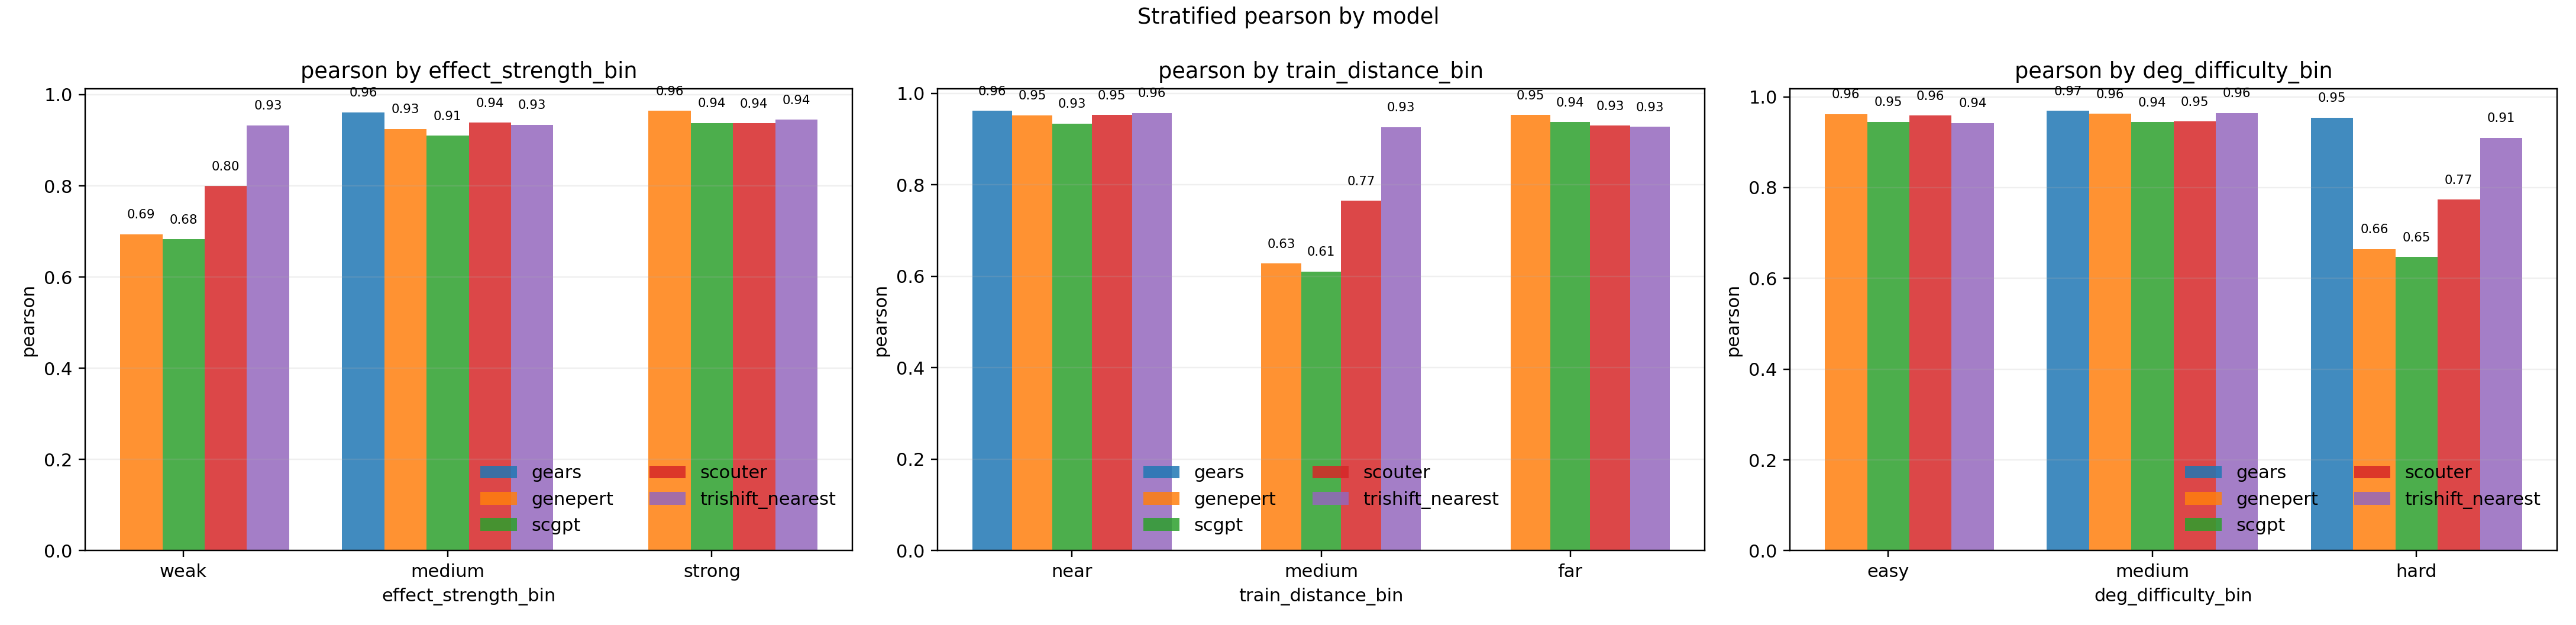

E:\CODE\trishift\artifacts\analysis\stratified_adamson\difficulty_scatter.png


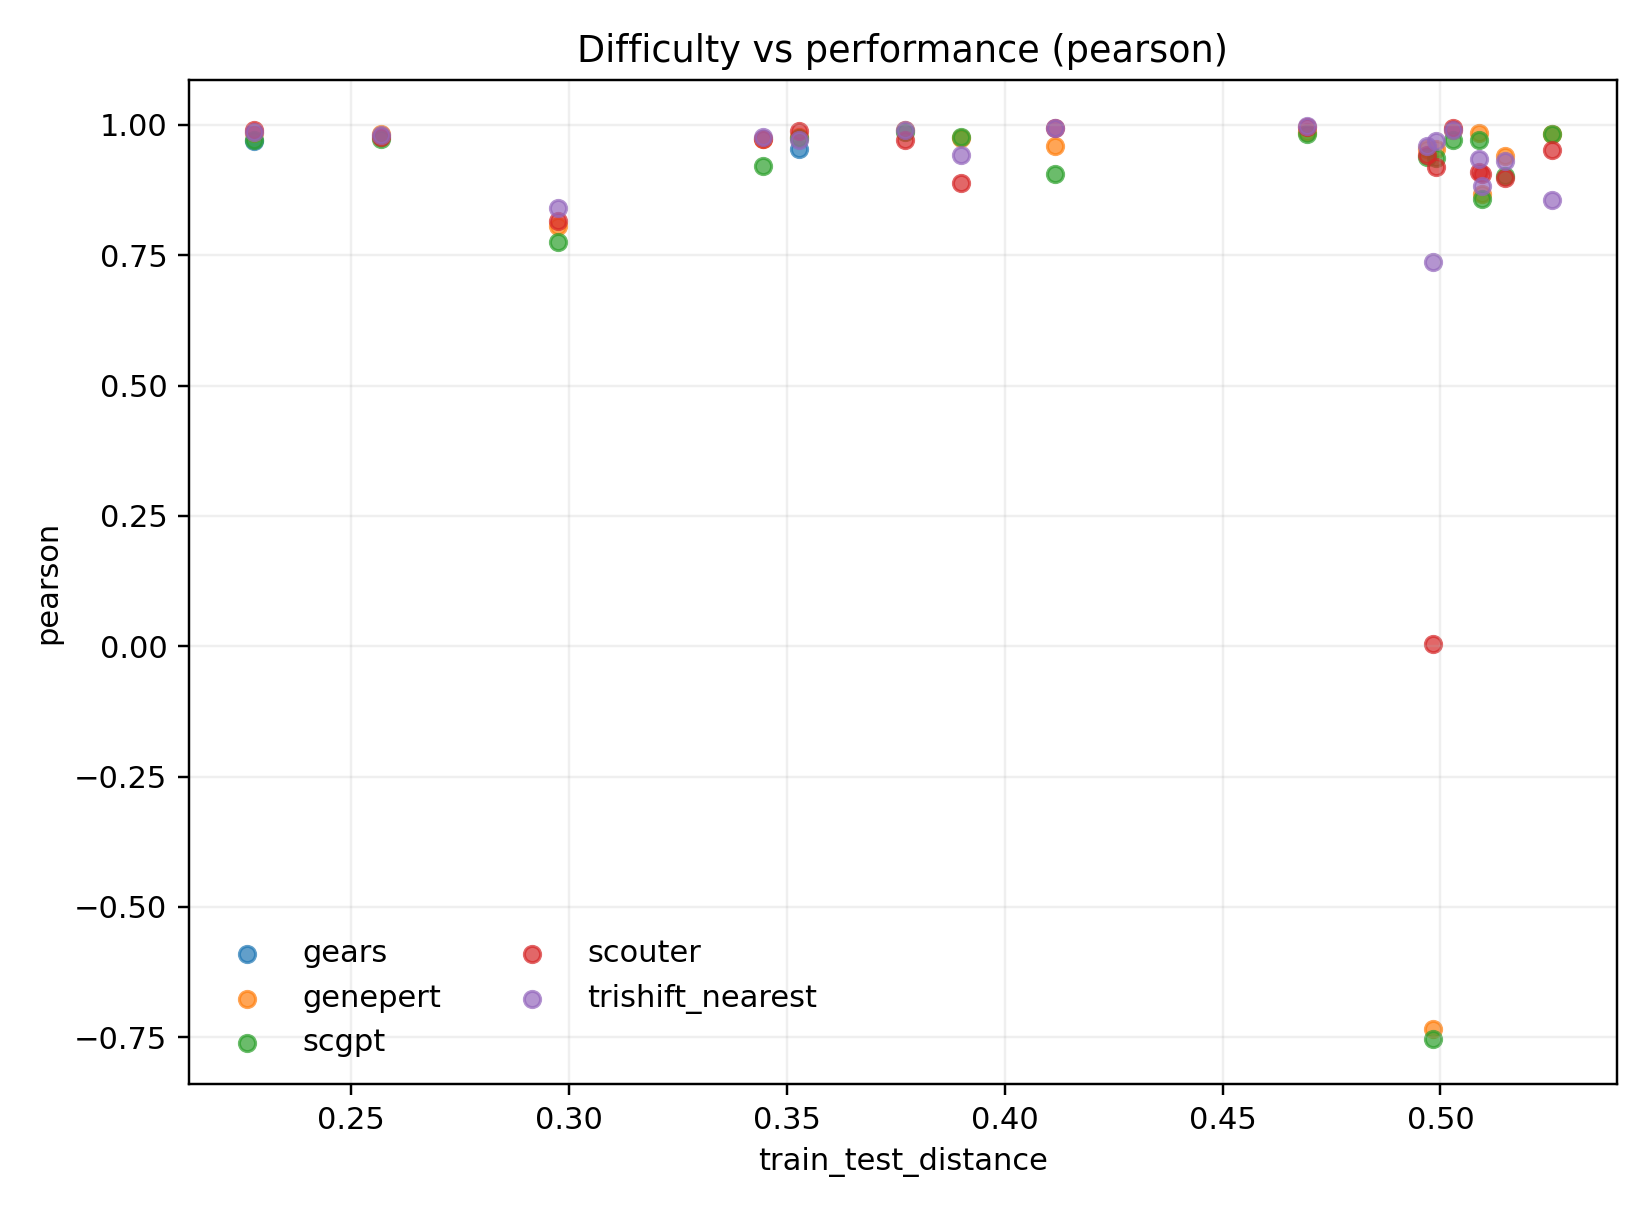

E:\CODE\trishift\artifacts\analysis\stratified_adamson\stratified_boxplot.png


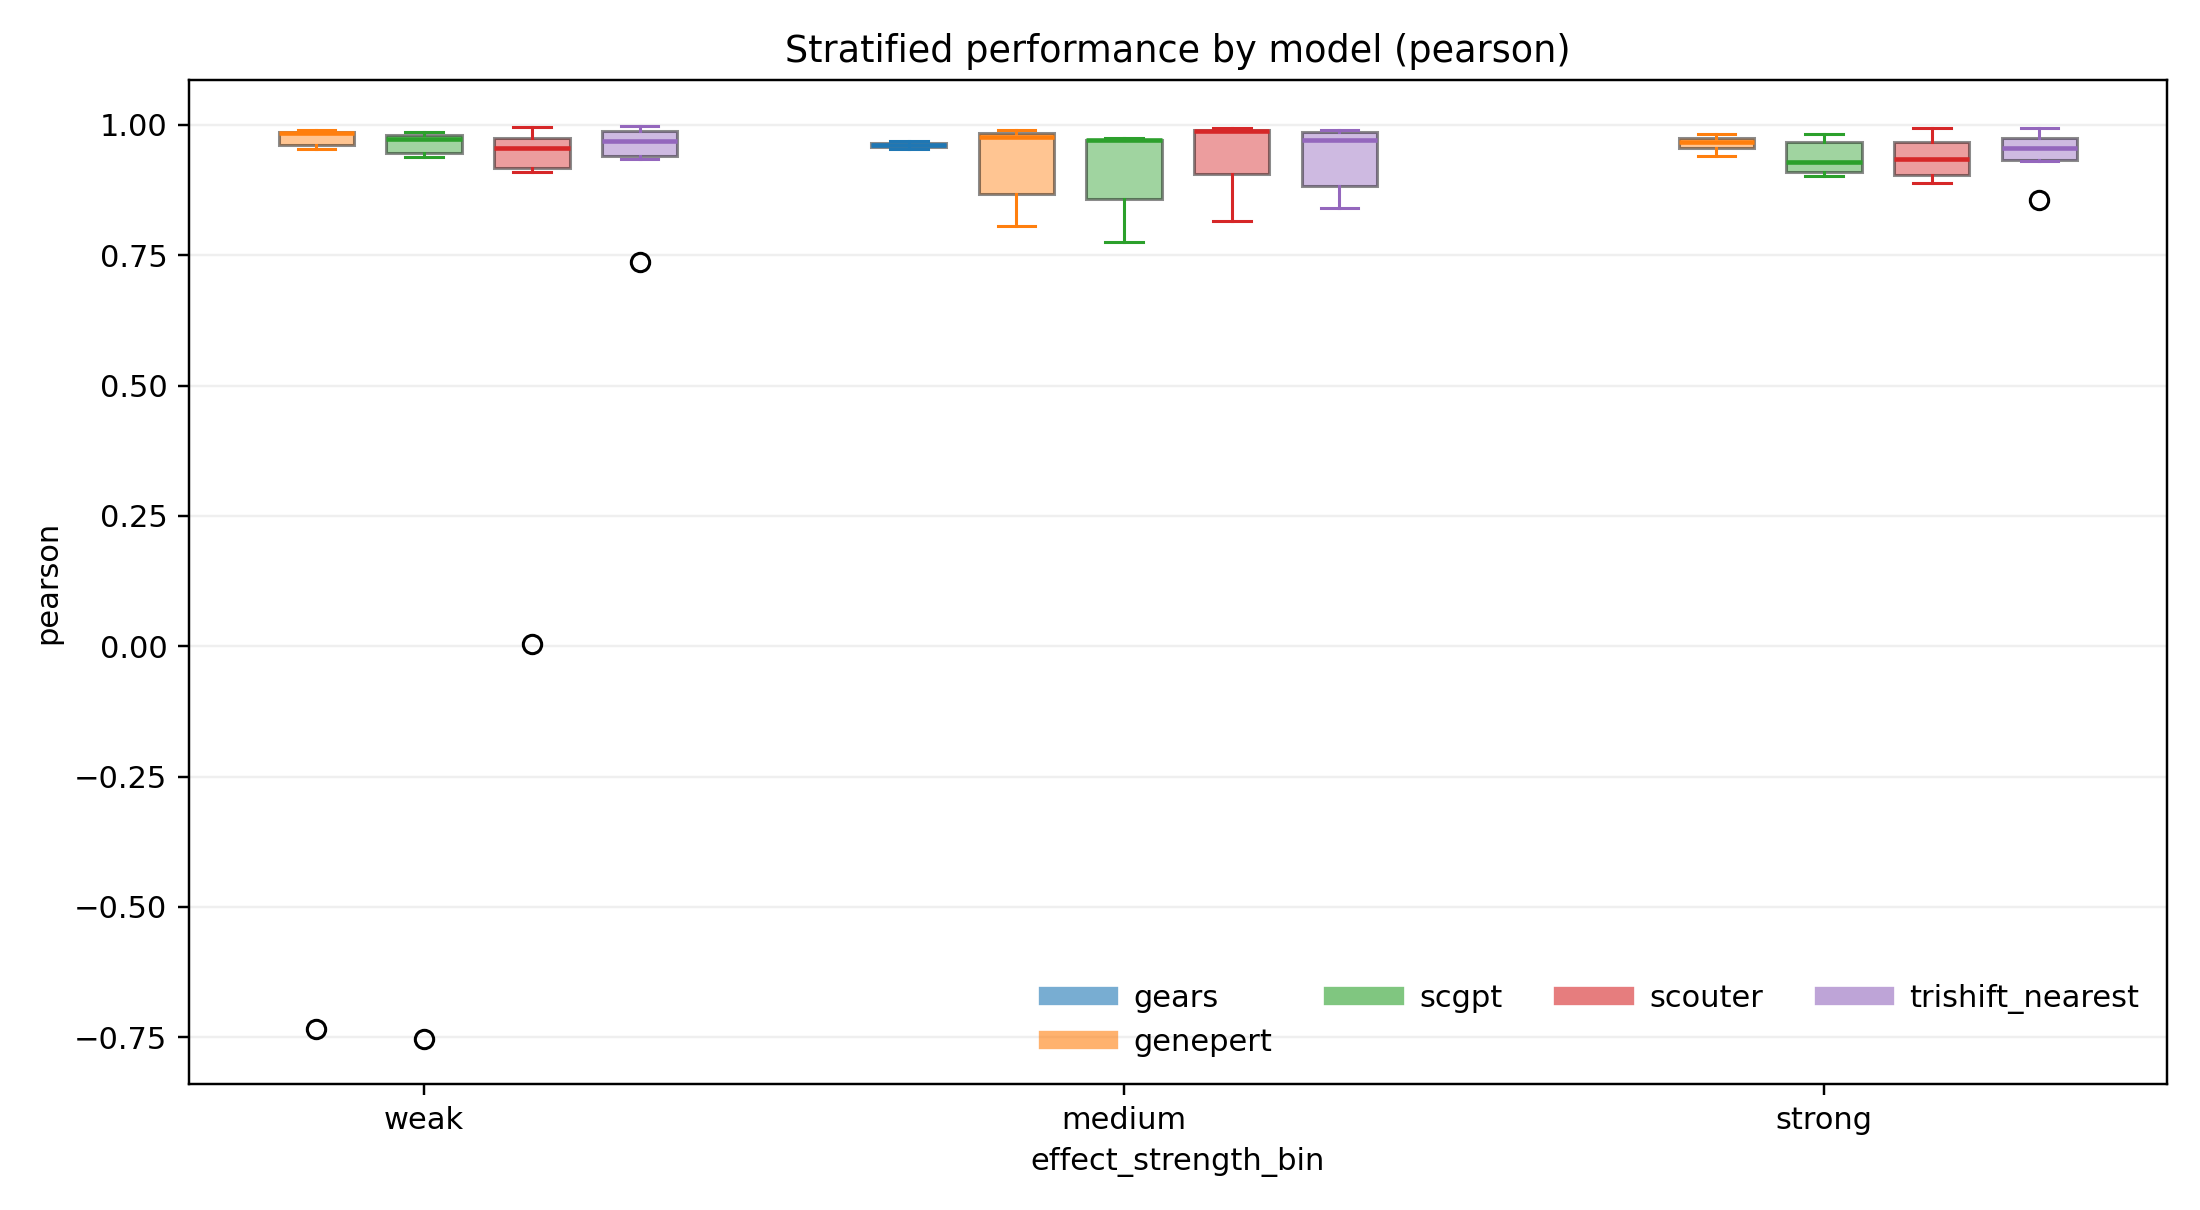

E:\CODE\trishift\artifacts\analysis\stratified_adamson\condition_difficulty_metadata.csv
E:\CODE\trishift\artifacts\analysis\stratified_adamson\stratified_metrics.csv
E:\CODE\trishift\artifacts\analysis\stratified_adamson\stratified_summary.csv
E:\CODE\trishift\artifacts\analysis\stratified_adamson\stratified_metric_means.csv
E:\CODE\trishift\artifacts\analysis\stratified_adamson\model_winrate_by_strata.csv
E:\CODE\trishift\artifacts\analysis\stratified_adamson\run_meta.json


In [4]:
out_dir = Path(result["out_dir"])
print(f"out_dir: {out_dir}")
print(f"summary metrics shown in barplot: {result.get('rendered_metrics', [])}")
display(result["metric_summary_df"])

for image_name in [
    "stratified_summary_barplot.png",
    "difficulty_scatter.png",
    "stratified_boxplot.png",
]:
    image_path = out_dir / image_name
    print(image_path)
    if image_path.exists():
        display(Image(filename=str(image_path)))
    else:
        print(f"missing: {image_path}")

for path in [
    out_dir / "condition_difficulty_metadata.csv",
    out_dir / "stratified_metrics.csv",
    out_dir / "stratified_summary.csv",
    out_dir / "stratified_metric_means.csv",
    out_dir / "model_winrate_by_strata.csv",
    out_dir / "run_meta.json",
]:
    print(path)
